In [1]:
import sys, os
import pandas as pd

# Caminho absoluto para o diretório raiz do projeto
project_root = os.path.abspath("...")  # se notebook estiver dentro de /notebooks
if project_root not in sys.path:
    sys.path.append(project_root)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Augmentações realistas (leves, médicas)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# ======================================================
# 📂 Carregamento dos datasets
# ======================================================

# --- Treino: originais + sintéticos ---
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Concatenar datasets de treino
train_raw = train_orig.concatenate(train_synth)

# --- Validação e Teste (apenas originais) ---
val_raw = tf.keras.utils.image_dataset_from_directory(
    "../data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Extrair classes e número de classes
CLASS_NAMES = val_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Classes detectadas:", CLASS_NAMES)

# ======================================================
# ⚡ Aplicar augmentation apenas no treino e prefetch
# ======================================================
train_ds = train_raw.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_raw.prefetch(tf.data.AUTOTUNE)
test_ds = test_raw.prefetch(tf.data.AUTOTUNE)


Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Classes detectadas: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia']


In [3]:
import sys
import os
import numpy as np  # Para contagens posteriores

# Caminho para o root do projeto (ajuste: '..' se notebook em /notebooks/, '.' se no root)
project_root = os.path.abspath("..")  # Exemplo comum para notebooks em subpastas
if project_root not in sys.path:
    sys.path.insert(0, project_root)  # Adiciona no início para priorizar

# Fallback: Adicione src explicitamente se necessário
src_path = os.path.join(project_root, 'src')
if os.path.exists(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

# Teste o import (rode isso para confirmar)
try:
    from src.VGG_help import build_vgg16
    print("✅ Import de src.VGG_help funcionando!")
except ImportError as e:
    print(f"❌ Ainda com erro: {e}")
    print("Debug: Diretório atual:", os.getcwd())
    print("Conteúdo do root:", os.listdir(project_root))

✅ Import de src.VGG_help funcionando!


#### Pneumonia vs Cardiomegaly

In [4]:
import tensorflow as tf
import numpy as np  # caso ainda não tenha importado

# ======================================================
# 📂 Carregamento do treino com dados sintéticos
# ======================================================
# Dados originais
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224,224), batch_size=BATCH_SIZE
)

# Dados sintéticos
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224,224), batch_size=BATCH_SIZE
)

# Concatenar datasets de treino
train_raw = train_orig.concatenate(train_synth)

# Validação e teste (apenas originais)
val_raw = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224,224), batch_size=BATCH_SIZE
)
test_raw = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224,224), batch_size=BATCH_SIZE
)

# Classes e índices binários
BINARY_CLASSES = ['Pneumonia', 'Cardiomegaly']
PNEUMONIA_IDX = val_raw.class_names.index('Pneumonia')
CARDIO_IDX = val_raw.class_names.index('Cardiomegaly')
NUM_CLASSES_BINARY = 2
print(f"Índices: Pneumonia={PNEUMONIA_IDX}, Cardiomegaly={CARDIO_IDX}")

# ======================================================
# ⚙️ Função para filtrar e remapear datasets binários
# ======================================================
def filter_and_remap(ds, pneumonia_idx, cardio_idx, batch_size):
    def filter_fn(img, label):
        keep = tf.logical_or(
            tf.equal(label, tf.constant(pneumonia_idx, dtype=label.dtype)),
            tf.equal(label, tf.constant(cardio_idx, dtype=label.dtype))
        )
        return keep
    
    def remap_fn(img, label):
        binary_label = tf.where(
            tf.equal(label, tf.constant(pneumonia_idx, dtype=label.dtype)), 0, 1
        )
        return img, binary_label
    
    return (ds.unbatch()
            .filter(filter_fn)
            .map(remap_fn)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# ======================================================
# 📦 Criar datasets binários
# ======================================================
train_raw_binary = filter_and_remap(train_raw, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
val_raw_binary = filter_and_remap(val_raw, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
test_raw_binary = filter_and_remap(test_raw, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)

# ⚡ Aplicar augmentation apenas no treino
train_ds_binary = train_raw_binary.map(lambda x, y: (data_augmentation(x, training=True), y))
val_ds_binary = val_raw_binary
test_ds_binary = test_raw_binary

# ======================================================
# 🔍 Verificação das contagens
# ======================================================
def count_binary_classes(ds):
    counts = {0: 0, 1: 0}
    for _, y in ds.take(1000):  # Limite para eficiência
        _, unique, cnts = tf.unique_with_counts(y)
        for u, c in zip(unique.numpy(), cnts.numpy()):
            counts[int(u)] += int(c)
    return counts

print("Amostras binárias (treino):", count_binary_classes(train_ds_binary))
print("Amostras binárias (validação):", count_binary_classes(val_ds_binary))
print("Amostras binárias (teste):", count_binary_classes(test_ds_binary))


Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Índices: Pneumonia=3, Cardiomegaly=1
Amostras binárias (treino): {0: 403, 1: 137}
Amostras binárias (validação): {0: 30, 1: 0}
Amostras binárias (teste): {0: 20, 1: 9}


In [5]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121, build_xception, build_custom_cnn,
    train_and_evaluate
)

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
BINARY_CLASSES = ["Pneumonia", "Cardiomegaly"]

# 🔹 Encontra índices corretos a partir de CLASS_NAMES
PNEUMONIA_IDX = CLASS_NAMES.index("Pneumonia")
CARDIO_IDX = CLASS_NAMES.index("Cardiomegaly")
print(f"Índices encontrados — Pneumonia: {PNEUMONIA_IDX}, Cardiomegaly: {CARDIO_IDX}")

# ======================================================
# 📂 Carregamento dos datasets base
# ======================================================

# Treino: originais + sintéticos
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224,224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224,224), batch_size=BATCH_SIZE
)
train_ds = train_orig.concatenate(train_synth)  # concatena originais + sintéticos

# Validação e teste (somente originais)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224,224), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224,224), batch_size=BATCH_SIZE
)

# ======================================================
# ⚙️ Filtragem binária (Pneumonia vs Cardiomegaly)
# ======================================================
train_ds_binary = filter_and_remap(train_ds, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
val_ds_binary = filter_and_remap(val_ds, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
test_ds_binary = filter_and_remap(test_ds, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================
train_orig_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(299,299), batch_size=BATCH_SIZE
)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(299,299), batch_size=BATCH_SIZE
)
train_ds_xcep = train_orig_xcep.concatenate(train_synth_xcep)  # treino com sintéticos

val_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(299,299), batch_size=BATCH_SIZE
)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(299,299), batch_size=BATCH_SIZE
)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
val_ds_xcep_bin = filter_and_remap(val_ds_xcep, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)
test_ds_xcep_bin = filter_and_remap(test_ds_xcep, PNEUMONIA_IDX, CARDIO_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos para treinamento binário
# ======================================================
model_configs = [
    (build_vgg16, (224, 224, 3), "VGG16_Binary"),
    (build_resnet50, (224, 224, 3), "ResNet50_Binary"),
    (build_densenet121, (224, 224, 3), "DenseNet121_Binary")
]

# ======================================================
# 🚀 Loop de Treinamento — Pneumonia vs Cardiomegaly
# ======================================================
binary_results_pneu_vs_cardio = {}
binary_histories = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Pneumonia vs Cardiomegaly ...")

    # Cria o modelo e executa o treino
    if name == "Xception_Binary":
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
            BINARY_CLASSES, epochs=50, title=name
        )
    else:
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_binary, val_ds_binary, test_ds_binary,
            BINARY_CLASSES, epochs=50, title=name
        )

    # Armazena resultados e histórico
    binary_results_pneu_vs_cardio[name] = metrics
    binary_histories[name] = history

    print(f"✅ {name} concluído — Métricas:", metrics)

print("\n🎯 Treinamento completo para todas as arquiteturas (Pneumonia vs Cardiomegaly).")


Índices encontrados — Pneumonia: 3, Cardiomegaly: 1
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando VGG16_Binary — Pneumonia vs Cardiomegaly ...
Epoch 1/50
     34/Unknown - 55s 2s/step - loss: 5.0899 - accuracy: 0.6796

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 62s 2s/step - loss: 5.0899 - accuracy: 0.6796 - val_loss: 7.4613 - val_accuracy: 0.6000
Epoch 2/50
34/34 [==============================] - 57s 2s/step - loss: 1.7729 - accuracy: 0.8574 - val_loss: 5.5419 - val_accuracy: 0.6333
Epoch 3/50
34/34 [==============================] - 50s 1s/step - loss: 0.7144 - accuracy: 0.9167 - val_loss: 25.4722 - val_accuracy: 0.5000
Epoch 4/50
34/34 [==============================] - 49s 1s/step - loss: 3.0507 - accuracy: 0.8352 - val_loss: 5.5166 - val_accuracy: 0.6333
Epoch 5/50
34/34 [==============================] - 50s 1s/step - loss: 0.2072 - accuracy: 0.9667 - val_loss: 6.9668 - val_accuracy: 0.6667
Epoch 6/50
34/34 [==============================] - 50s 1s/step - loss: 0.1805 - accuracy: 0.9741 - val_loss: 2.7814 - val_accuracy: 0.7667
Epoch 7/50
34/34 [==============================] - 49s 1s/step - loss: 0.0325 - accuracy: 0.9889 - val_loss: 2.7916 - val_accuracy: 0.7667
Epoch 8/50
34/34 [============

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 33s 886ms/step - loss: 0.7110 - accuracy: 0.5648 - val_loss: 0.7872 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 31s 905ms/step - loss: 0.6088 - accuracy: 0.6630 - val_loss: 0.7359 - val_accuracy: 0.5333
Epoch 3/50
34/34 [==============================] - 30s 879ms/step - loss: 0.5477 - accuracy: 0.7222 - val_loss: 0.7082 - val_accuracy: 0.6333
Epoch 4/50
34/34 [==============================] - 29s 838ms/step - loss: 0.5081 - accuracy: 0.7500 - val_loss: 0.6891 - val_accuracy: 0.6000
Epoch 5/50
34/34 [==============================] - 29s 850ms/step - loss: 0.4819 - accuracy: 0.7759 - val_loss: 0.6690 - val_accuracy: 0.6333
Epoch 6/50
34/34 [==============================] - 29s 833ms/step - loss: 0.4608 - accuracy: 0.7870 - val_loss: 0.6516 - val_accuracy: 0.7000
Epoch 7/50
34/34 [==============================] - 29s 846ms/step - loss: 0.4390 - accuracy: 0.8056 - val_loss: 0.6421 - val_accuracy: 0.7000
Epoch 8/50

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 42s 1s/step - loss: 3.1159 - accuracy: 0.4907 - val_loss: 1.2371 - val_accuracy: 0.4667
Epoch 2/50
34/34 [==============================] - 31s 904ms/step - loss: 1.1623 - accuracy: 0.4722 - val_loss: 1.0579 - val_accuracy: 0.5000
Epoch 3/50
34/34 [==============================] - 31s 894ms/step - loss: 0.9799 - accuracy: 0.5056 - val_loss: 0.8740 - val_accuracy: 0.4667
Epoch 4/50
34/34 [==============================] - 32s 914ms/step - loss: 0.8618 - accuracy: 0.5333 - val_loss: 0.7765 - val_accuracy: 0.5667
Epoch 5/50
34/34 [==============================] - 32s 917ms/step - loss: 0.7881 - accuracy: 0.5667 - val_loss: 0.7343 - val_accuracy: 0.6333
Epoch 6/50
34/34 [==============================] - 31s 884ms/step - loss: 0.7446 - accuracy: 0.5889 - val_loss: 0.7361 - val_accuracy: 0.6000
Epoch 7/50
34/34 [==============================] - 32s 914ms/step - loss: 0.7240 - accuracy: 0.5981 - val_loss: 0.7418 - val_accuracy: 0.6000
Epoch 8/50
34


📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Pneumonia_vs_Cardiomegaly_comparison.csv

📊 Comparação Final (Pneumonia vs Cardiomegaly):
                    Accuracy  Weighted F1  Macro F1   AUROC
VGG16_Binary          0.7586       0.7496    0.7478  0.8167
ResNet50_Binary       0.7241       0.7221    0.7212  0.8952
DenseNet121_Binary    0.6552       0.6527    0.6514  0.7048


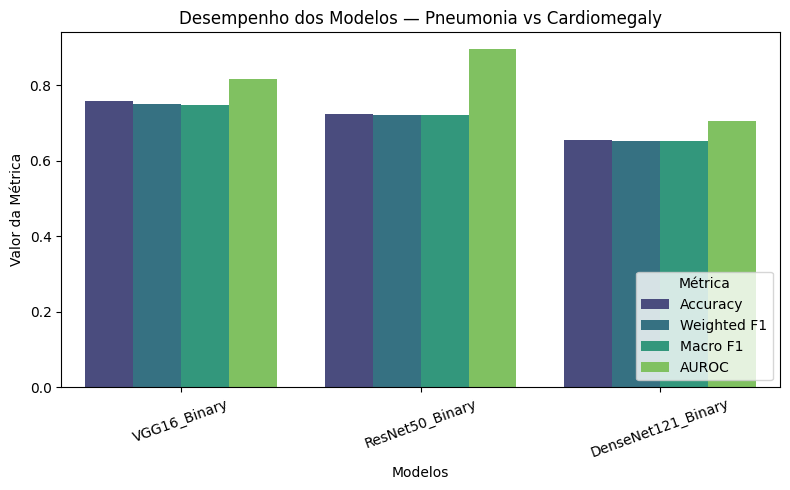

In [6]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados para DataFrame
comparison_df = pd.DataFrame(binary_results_pneu_vs_cardio).T
comparison_df = comparison_df.round(4)

# Salva CSV com resumo
csv_path = "Trained_Models/Pneumonia_vs_Cardiomegaly_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe no console
print("\n📊 Comparação Final (Pneumonia vs Cardiomegaly):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho
# ======================================================
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df.reset_index().melt(id_vars="index"),
            x="index", y="value", hue="variable", palette="viridis")
plt.title("Desempenho dos Modelos — Pneumonia vs Cardiomegaly")
plt.xlabel("Modelos")
plt.ylabel("Valor da Métrica")
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("Trained_Models/Pneumonia_vs_Cardiomegaly_metrics.png", dpi=300)
plt.show()

#### Atelectasis vs Penumonia 

Índices encontrados — Atelectasis: 0, Pneumonia: 3
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando VGG16_Binary — Atelectasis vs Pneumonia ...
🔁 Execução 1/3
Epoch 1/50
     34/Unknown - 66s 2s/step - loss: 6.6452 - accuracy: 0.6407

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 71s 2s/step - loss: 6.6452 - accuracy: 0.6407 - val_loss: 5.8842 - val_accuracy: 0.5333
Epoch 2/50
34/34 [==============================] - 65s 2s/step - loss: 1.2478 - accuracy: 0.8796 - val_loss: 8.5538 - val_accuracy: 0.5667
Epoch 3/50
34/34 [==============================] - 60s 2s/step - loss: 0.7220 - accuracy: 0.9296 - val_loss: 5.0584 - val_accuracy: 0.5667
Epoch 4/50
34/34 [==============================] - 54s 2s/step - loss: 0.2736 - accuracy: 0.9574 - val_loss: 5.3844 - val_accuracy: 0.6000
Epoch 5/50
34/34 [==============================] - 54s 2s/step - loss: 0.2919 - accuracy: 0.9648 - val_loss: 7.5698 - val_accuracy: 0.6000
Epoch 6/50
34/34 [==============================] - 52s 2s/step - loss: 0.1172 - accuracy: 0.9796 - val_loss: 4.2856 - val_accuracy: 0.6000
Epoch 7/50
34/34 [==============================] - 55s 2s/step - loss: 0.0883 - accuracy: 0.9815 - val_loss: 3.8769 - val_accuracy: 0.7000
Epoch 8/50
34/34 [=============

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 55s 2s/step - loss: 4.7673 - accuracy: 0.6593 - val_loss: 24.5344 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 57s 2s/step - loss: 2.6936 - accuracy: 0.8500 - val_loss: 9.5127 - val_accuracy: 0.5667
Epoch 3/50
34/34 [==============================] - 54s 2s/step - loss: 0.6086 - accuracy: 0.9278 - val_loss: 10.6773 - val_accuracy: 0.5333
Epoch 4/50
34/34 [==============================] - 54s 2s/step - loss: 1.0808 - accuracy: 0.9167 - val_loss: 7.7588 - val_accuracy: 0.6667
Epoch 5/50
34/34 [==============================] - 55s 2s/step - loss: 0.1611 - accuracy: 0.9630 - val_loss: 11.3941 - val_accuracy: 0.4667
Epoch 6/50
34/34 [==============================] - 51s 1s/step - loss: 0.2159 - accuracy: 0.9667 - val_loss: 8.5294 - val_accuracy: 0.5000
Epoch 7/50
34/34 [==============================] - 52s 2s/step - loss: 0.1855 - accuracy: 0.9741 - val_loss: 11.0946 - val_accuracy: 0.5333
Epoch 8/50
34/34 [=========

...

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 44s 1s/step - loss: 1.8660 - accuracy: 0.4481 - val_loss: 0.8093 - val_accuracy: 0.6667
Epoch 2/50
34/34 [==============================] - 34s 952ms/step - loss: 1.2506 - accuracy: 0.4519 - val_loss: 0.7942 - val_accuracy: 0.6333
Epoch 3/50
34/34 [==============================] - 35s 1s/step - loss: 1.1443 - accuracy: 0.4778 - val_loss: 0.8777 - val_accuracy: 0.6000
Epoch 4/50
34/34 [==============================] - 35s 1s/step - loss: 1.0937 - accuracy: 0.5167 - val_loss: 0.9181 - val_accuracy: 0.6333
Epoch 5/50
34/34 [==============================] - 33s 960ms/step - loss: 1.0612 - accuracy: 0.5148 - val_loss: 0.9029 - val_accuracy: 0.6333
Epoch 6/50
34/34 [==============================] - 37s 1s/step - loss: 1.0270 - accuracy: 0.5333 - val_loss: 0.9884 - val_accuracy: 0.6333
Epoch 7/50
1/1 [==============================] - 1s 750ms/step
✅ Training finished for DenseNet121_Binary_run2
{'Accuracy': 0.4482758620689655, 'Weighted F1': 0.427

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 50s 1s/step - loss: 2.2307 - accuracy: 0.5370 - val_loss: 1.6265 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 35s 1s/step - loss: 1.1784 - accuracy: 0.5593 - val_loss: 1.4462 - val_accuracy: 0.5333
Epoch 3/50
34/34 [==============================] - 37s 1s/step - loss: 1.0926 - accuracy: 0.5796 - val_loss: 1.3907 - val_accuracy: 0.5333
Epoch 4/50
34/34 [==============================] - 37s 1s/step - loss: 1.0524 - accuracy: 0.5741 - val_loss: 1.3590 - val_accuracy: 0.5333
Epoch 5/50
34/34 [==============================] - 39s 1s/step - loss: 1.0181 - accuracy: 0.5630 - val_loss: 1.2437 - val_accuracy: 0.5333
Epoch 6/50
34/34 [==============================] - 38s 1s/step - loss: 0.9776 - accuracy: 0.5519 - val_loss: 1.2342 - val_accuracy: 0.5667
Epoch 7/50
34/34 [==============================] - 36s 1s/step - loss: 0.9496 - accuracy: 0.5611 - val_loss: 1.1723 - val_accuracy: 0.5000
Epoch 8/50
34/34 [=============

<Figure size 800x500 with 0 Axes>

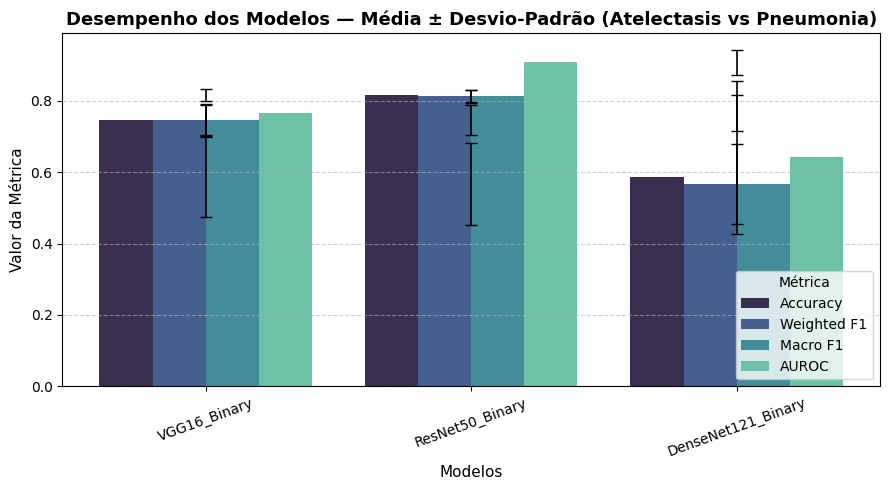

📊 Gráfico salvo em: Trained_Models/Atelectasis_vs_Pneumonia_metrics.png


In [13]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121, build_xception, build_custom_cnn,
    train_and_evaluate
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
BINARY_CLASSES = ["Atelectasis", "Pneumonia"]
N_RUNS = 3  # número de execuções por modelo para média e desvio padrão

# 🔹 Encontra índices corretos a partir de CLASS_NAMES
ATELECTASIS_IDX = CLASS_NAMES.index("Atelectasis")
PNEUMONIA_IDX = CLASS_NAMES.index("Pneumonia")

print(f"Índices encontrados — Atelectasis: {ATELECTASIS_IDX}, Pneumonia: {PNEUMONIA_IDX}")

# ======================================================
# 📂 Carregamento dos datasets base
# ======================================================
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224,224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224,224), batch_size=BATCH_SIZE
)
train_ds = train_orig.concatenate(train_synth)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224,224), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224,224), batch_size=BATCH_SIZE
)

# ⚙️ Filtragem binária (Atelectasis vs Pneumonia)
train_ds_binary = filter_and_remap(train_ds, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)
val_ds_binary = filter_and_remap(val_ds, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)
test_ds_binary = filter_and_remap(test_ds, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================
train_orig_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(299,299), batch_size=BATCH_SIZE
)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(299,299), batch_size=BATCH_SIZE
)
train_ds_xcep = train_orig_xcep.concatenate(train_synth_xcep)

val_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(299,299), batch_size=BATCH_SIZE
)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(299,299), batch_size=BATCH_SIZE
)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)
val_ds_xcep_bin = filter_and_remap(val_ds_xcep, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)
test_ds_xcep_bin = filter_and_remap(test_ds_xcep, ATELECTASIS_IDX, PNEUMONIA_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos
# ======================================================
model_configs = [
    (build_vgg16, (224, 224, 3), "VGG16_Binary"),
    (build_resnet50, (224, 224, 3), "ResNet50_Binary"),
    (build_densenet121, (224, 224, 3), "DenseNet121_Binary"),
]

# ======================================================
# 🚀 Treinamento — Atelectasis vs Pneumonia
# ======================================================
binary_results_atel_vs_pneu = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Atelectasis vs Pneumonia ...")

    run_metrics = []

    for run in range(N_RUNS):
        print(f"🔁 Execução {run+1}/{N_RUNS}")

        if name == "Xception_Binary":
            model = builder(input_shape, NUM_CLASSES_BINARY)
            history, metrics = train_and_evaluate(
                model,
                train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
                BINARY_CLASSES, epochs=50, title=f"{name}_run{run+1}"
            )
        else:
            model = builder(input_shape, NUM_CLASSES_BINARY)
            history, metrics = train_and_evaluate(
                model,
                train_ds_binary, val_ds_binary, test_ds_binary,
                BINARY_CLASSES, epochs=50, title=f"{name}_run{run+1}"
            )

        run_metrics.append(metrics)

    # 🔹 Calcula média e desvio padrão
    metrics_mean = {f"{k}_mean": np.mean([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}
    metrics_std = {f"{k}_std": np.std([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}

    binary_results_atel_vs_pneu[name] = {**metrics_mean, **metrics_std}
    print(f"✅ {name} concluído — Métricas médias:", metrics_mean)

print("\n🎯 Treinamento completo para todas as arquiteturas (Atelectasis vs Pneumonia).")

# ======================================================
# 💾 Salvar resultados e gráfico
# ======================================================
os.makedirs("Trained_Models", exist_ok=True)

comparison_df = pd.DataFrame(binary_results_atel_vs_pneu).T
csv_path = "Trained_Models/Atelectasis_vs_Pneumonia_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"\n📄 Resultados salvos em: {csv_path}")

print("\n📊 Comparação Final (Atelectasis vs Pneumonia):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico — Média ± Desvio Padrão
# ======================================================
plt.figure(figsize=(8, 5))
comparison_df.columns = comparison_df.columns.astype(str)

mean_cols = [c for c in comparison_df.columns if c.endswith("_mean")]
std_cols = [c.replace("_mean", "_std") for c in mean_cols]

plot_df = comparison_df[mean_cols].reset_index().melt(
    id_vars="index", var_name="metric", value_name="mean"
)
plot_df["std"] = plot_df.apply(
    lambda row: comparison_df.loc[row["index"], row["metric"].replace("_mean", "_std")]
    if row["metric"].replace("_mean", "_std") in comparison_df.columns
    else np.nan,
    axis=1
)
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "", regex=False)

palette = sns.color_palette("mako", n_colors=len(plot_df["metric"].unique()))
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(data=plot_df, x="index", y="mean", hue="metric", palette=palette, errorbar=None)

# Adiciona manualmente as barras de erro
for i, row in plot_df.iterrows():
    ax.errorbar(
        x=i // len(plot_df["metric"].unique()),
        y=row["mean"],
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4
    )

ax.set_title("Desempenho dos Modelos — Média ± Desvio-Padrão (Atelectasis vs Pneumonia)",
             fontsize=13, weight="bold")
ax.set_xlabel("Modelos", fontsize=11)
ax.set_ylabel("Valor da Métrica", fontsize=11)
ax.legend(title="Métrica", loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=20)
plt.tight_layout()

plot_path = "Trained_Models/Atelectasis_vs_Pneumonia_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")



📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Atelectasis_vs_Pneumonia_comparison.csv

📊 Comparação Final (Atelectasis vs Pneumonia):
                    Accuracy_mean  Weighted F1_mean  Macro F1_mean  \
VGG16_Binary               0.7471            0.7452         0.7455   
ResNet50_Binary            0.8161            0.8127         0.8117   
DenseNet121_Binary         0.5862            0.5673         0.5663   

                    AUROC_mean  Accuracy_std  Weighted F1_std  Macro F1_std  \
VGG16_Binary            0.7651        0.0430           0.0429        0.0428   
ResNet50_Binary         0.9079        0.0163           0.0175        0.0177   
DenseNet121_Binary      0.6413        0.1126           0.1149        0.1126   

                    AUROC_std  
VGG16_Binary           0.0514  
ResNet50_Binary        0.0348  
DenseNet121_Binary     0.2133  


<Figure size 800x500 with 0 Axes>

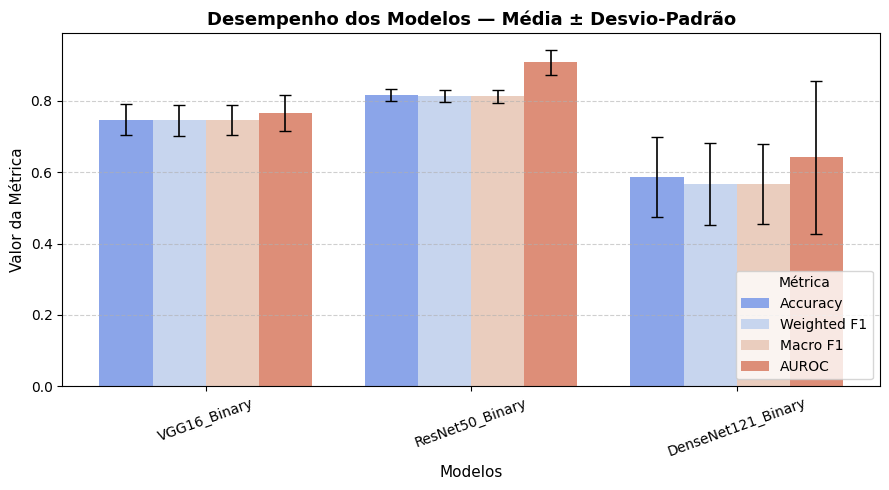

📊 Gráfico salvo em: Trained_Models/Atelectasis_vs_Pneumonia_metrics.png


In [14]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Atelectasis vs Pneumonia
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída (caso não exista)
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados em DataFrame
comparison_df = pd.DataFrame(binary_results_atel_vs_pneu).T
comparison_df = comparison_df.round(4)

# Caminho de salvamento
csv_path = "Trained_Models/Atelectasis_vs_Pneumonia_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

print("\n📊 Comparação Final (Atelectasis vs Pneumonia):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho — com desvio-padrão
# ======================================================

plt.figure(figsize=(8, 5))

# Garante que os nomes das colunas sejam strings
comparison_df.columns = comparison_df.columns.astype(str)

# Seleciona colunas de médias e desvios
mean_cols = [c for c in comparison_df.columns if c.endswith("_mean")]
std_cols = [c.replace("_mean", "_std") for c in mean_cols]

# Cria DataFrame "longo" (tidy)
plot_df = comparison_df[mean_cols].reset_index().melt(
    id_vars="index", var_name="metric", value_name="mean"
)

# Adiciona coluna de desvio padrão correspondente
plot_df["std"] = plot_df.apply(
    lambda row: comparison_df.loc[row["index"], row["metric"].replace("_mean", "_std")]
    if row["metric"].replace("_mean", "_std") in comparison_df.columns
    else np.nan,
    axis=1
)

# Remove o sufixo "_mean" para exibir no gráfico
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "", regex=False)

# Define cores
palette = sns.color_palette("coolwarm", n_colors=len(plot_df["metric"].unique()))

# Cria gráfico de barras
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x="index",
    y="mean",
    hue="metric",
    palette=palette,
    errorbar=None  # Desativamos para adicionar manualmente o desvio padrão
)

# Adiciona manualmente as barras de erro (desvio-padrão)
for i, row in enumerate(plot_df.itertuples()):
    model_idx = list(plot_df["index"].unique()).index(row.index)
    metric_idx = list(plot_df["metric"].unique()).index(row.metric)
    ax.errorbar(
        x=model_idx + (metric_idx - len(plot_df["metric"].unique())/2) * 0.2 + 0.1,
        y=row.mean,
        yerr=row.std,
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4
    )

# Configurações visuais
ax.set_title("Desempenho dos Modelos — Média ± Desvio-Padrão", fontsize=13, weight="bold")
ax.set_xlabel("Modelos", fontsize=11)
ax.set_ylabel("Valor da Métrica", fontsize=11)
ax.legend(title="Métrica", loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=20)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Atelectasis_vs_Pneumonia_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")


#### Effusion vs Pneumonia

Índices encontrados — Effusion: 2, Pneumonia: 3
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando DenseNet121_Binary — Effusion vs Pneumonia ...
🔁 Execução 1/3
Epoch 1/50
     34/Unknown - 41s 961ms/step - loss: 3.0372 - accuracy: 0.5185

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 46s 1s/step - loss: 3.0372 - accuracy: 0.5185 - val_loss: 2.0006 - val_accuracy: 0.4333
Epoch 2/50
34/34 [==============================] - 38s 1s/step - loss: 1.5520 - accuracy: 0.5019 - val_loss: 1.6933 - val_accuracy: 0.4667
Epoch 3/50
34/34 [==============================] - 36s 1s/step - loss: 1.2863 - accuracy: 0.5259 - val_loss: 1.2789 - val_accuracy: 0.5000
Epoch 4/50
34/34 [==============================] - 36s 1s/step - loss: 1.0291 - accuracy: 0.5704 - val_loss: 0.9747 - val_accuracy: 0.6667
Epoch 5/50
34/34 [==============================] - 37s 1s/step - loss: 0.8475 - accuracy: 0.6148 - val_loss: 0.8237 - val_accuracy: 0.7000
Epoch 6/50
34/34 [==============================] - 34s 987ms/step - loss: 0.7333 - accuracy: 0.6537 - val_loss: 0.8014 - val_accuracy: 0.7000
Epoch 7/50
34/34 [==============================] - 34s 976ms/step - loss: 0.6743 - accuracy: 0.6778 - val_loss: 0.8225 - val_accuracy: 0.6667
Epoch 8/50
34/34 [=======

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 41s 1s/step - loss: 4.9103 - accuracy: 0.4981 - val_loss: 1.0540 - val_accuracy: 0.5333
Epoch 2/50
34/34 [==============================] - 33s 959ms/step - loss: 1.5037 - accuracy: 0.4167 - val_loss: 1.0940 - val_accuracy: 0.6000
Epoch 3/50
34/34 [==============================] - 31s 908ms/step - loss: 1.4149 - accuracy: 0.4315 - val_loss: 1.0926 - val_accuracy: 0.6000
Epoch 4/50
34/34 [==============================] - 34s 977ms/step - loss: 1.3441 - accuracy: 0.4519 - val_loss: 1.1493 - val_accuracy: 0.6000
Epoch 5/50
34/34 [==============================] - 34s 973ms/step - loss: 1.2906 - accuracy: 0.4648 - val_loss: 1.1926 - val_accuracy: 0.5667
Epoch 6/50
1/1 [==============================] - 1s 708ms/step
✅ Training finished for DenseNet121_Binary_run2
{'Accuracy': 0.3793103448275862, 'Weighted F1': 0.37035809018567645, 'Macro F1': 0.37259615384615385, 'AUROC': 0.3476190476190476}
🔁 Execução 3/3
Epoch 1/50
     34/Unknown - 38s 961ms/st

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 42s 1s/step - loss: 1.1036 - accuracy: 0.5500 - val_loss: 1.2508 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 36s 1s/step - loss: 0.9962 - accuracy: 0.5704 - val_loss: 1.1084 - val_accuracy: 0.5667
Epoch 3/50
34/34 [==============================] - 35s 1s/step - loss: 0.9180 - accuracy: 0.6056 - val_loss: 1.0502 - val_accuracy: 0.6000
Epoch 4/50
34/34 [==============================] - 33s 962ms/step - loss: 0.8586 - accuracy: 0.6204 - val_loss: 0.9712 - val_accuracy: 0.6000
Epoch 5/50
34/34 [==============================] - 38s 1s/step - loss: 0.8054 - accuracy: 0.6167 - val_loss: 0.8744 - val_accuracy: 0.6000
Epoch 6/50
34/34 [==============================] - 35s 1s/step - loss: 0.7603 - accuracy: 0.6537 - val_loss: 0.8728 - val_accuracy: 0.6333
Epoch 7/50
34/34 [==============================] - 34s 983ms/step - loss: 0.7316 - accuracy: 0.6593 - val_loss: 0.8896 - val_accuracy: 0.6333
Epoch 8/50
34/34 [=======

<Figure size 800x500 with 0 Axes>

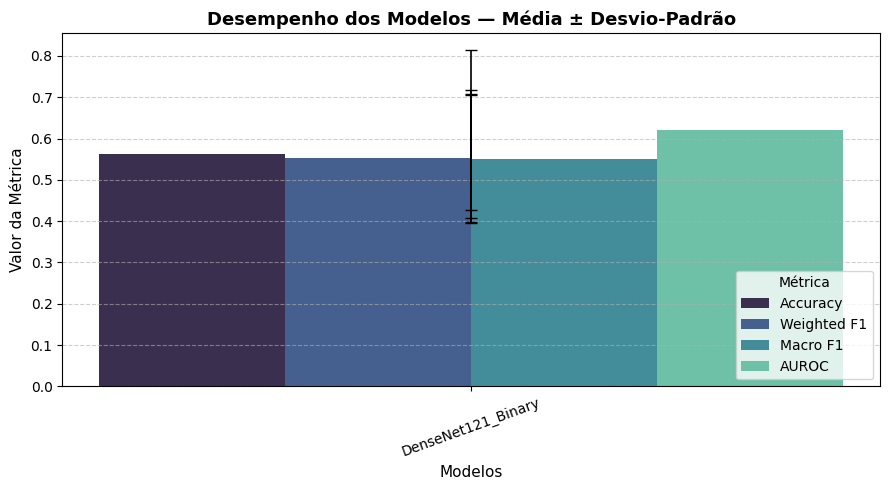

📊 Gráfico salvo em: Trained_Models/Effusion_vs_Pneumonia_metrics.png


In [11]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121, build_xception, build_custom_cnn,
    train_and_evaluate
)

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
BINARY_CLASSES = ["Effusion", "Pneumonia"]

N_RUNS = 3  # número de execuções para calcular desvio padrão
# 🔹 Encontra índices corretos a partir de CLASS_NAMES
EFFUSION_IDX = CLASS_NAMES.index("Effusion")
PNEUMONIA_IDX = CLASS_NAMES.index("Pneumonia")

print(f"Índices encontrados — Effusion: {EFFUSION_IDX}, Pneumonia: {PNEUMONIA_IDX}")

# ======================================================
# 📂 Carregamento dos datasets base (224x224)
# ======================================================

# Treino: originais + sintéticos
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_ds = train_orig.concatenate(train_synth)  # concatena originais + sintéticos

# Validação e teste (somente originais)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224, 224), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224, 224), batch_size=BATCH_SIZE
)

# ======================================================
# ⚙️ Filtragem binária (Effusion vs Pneumonia)
# ======================================================
train_ds_binary = filter_and_remap(train_ds, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)
val_ds_binary = filter_and_remap(val_ds, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)
test_ds_binary = filter_and_remap(test_ds, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================

# Treino: originais + sintéticos (resolução 299x299)
train_orig_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_ds_xcep = train_orig_xcep.concatenate(train_synth_xcep)

# Validação e teste (somente originais)
val_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(299, 299), batch_size=BATCH_SIZE
)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(299, 299), batch_size=BATCH_SIZE
)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)
val_ds_xcep_bin = filter_and_remap(val_ds_xcep, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)
test_ds_xcep_bin = filter_and_remap(test_ds_xcep, EFFUSION_IDX, PNEUMONIA_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos para treinamento binário
# ======================================================
model_configs = [

    (build_densenet121, (224, 224, 3), "DenseNet121_Binary")
]

# ======================================================
# 🚀 Loop de Treinamento — Effusion vs Pneumonia
# ======================================================
binary_results_eff_vs_pneu = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Effusion vs Pneumonia ...")

    run_metrics = []  # lista para armazenar métricas de várias execuções

    for run in range(N_RUNS):
        print(f"🔁 Execução {run + 1}/{N_RUNS}")

        if name == "Xception_Binary":
            model = builder(input_shape, NUM_CLASSES_BINARY)
            history, metrics = train_and_evaluate(
                model,
                train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
                BINARY_CLASSES, epochs=50, title=f"{name}_run{run+1}"
            )
        else:
            model = builder(input_shape, NUM_CLASSES_BINARY)
            history, metrics = train_and_evaluate(
                model,
                train_ds_binary, val_ds_binary, test_ds_binary,
                BINARY_CLASSES, epochs=50, title=f"{name}_run{run+1}"
            )

        run_metrics.append(metrics)

    # 🔹 Calcula média e desvio padrão
    metrics_mean = {f"{k}_mean": np.mean([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}
    metrics_std = {f"{k}_std": np.std([m[k] for m in run_metrics]) for k in run_metrics[0].keys()}

    # Combina e salva
    combined_metrics = {**metrics_mean, **metrics_std}
    binary_results_eff_vs_pneu[name] = combined_metrics

    print(f"✅ {name} concluído — Métricas médias:", metrics_mean)


print("\n🎯 Treinamento completo para todas as arquiteturas (Effusion vs Pneumonia).")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# ======================================================
# 💾 Salvar resultados — Médias e Desvios
# ======================================================

os.makedirs("Trained_Models", exist_ok=True)

# Cria DataFrame consolidado
comparison_df = pd.DataFrame(binary_results_eff_vs_pneu).T

# Salva CSV
csv_path = "Trained_Models/Effusion_vs_Pneumonia_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"\n📄 Resultados salvos em: {csv_path}")

print("\n📊 Comparação Final (Effusion vs Pneumonia):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico — Métricas com desvio padrão
# ======================================================

plt.figure(figsize=(8, 5))

# Corrige tipo de coluna
comparison_df.columns = comparison_df.columns.astype(str)

# Seleciona colunas de médias e desvios
mean_cols = [c for c in comparison_df.columns if c.endswith("_mean")]
std_cols = [c.replace("_mean", "_std") for c in mean_cols]

# Cria DataFrame "longo"
plot_df = comparison_df[mean_cols].reset_index().melt(
    id_vars="index", var_name="metric", value_name="mean"
)

# Adiciona desvio correspondente
plot_df["std"] = plot_df.apply(
    lambda row: comparison_df.loc[row["index"], row["metric"].replace("_mean", "_std")]
    if row["metric"].replace("_mean", "_std") in comparison_df.columns
    else np.nan,
    axis=1
)

# Remove o sufixo "_mean" para exibir no gráfico
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "", regex=False)

# Cria gráfico com barras + erro
palette = sns.color_palette("mako", n_colors=len(plot_df["metric"].unique()))
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=plot_df,
    x="index", y="mean", hue="metric",
    palette=palette,
    errorbar=None
)

# Adiciona manualmente as barras de erro
for i, row in plot_df.iterrows():
    ax.errorbar(
        x=i // len(plot_df["metric"].unique()),  # agrupa por modelo
        y=row["mean"],
        yerr=row["std"],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4
    )

ax.set_title("Desempenho dos Modelos — Média ± Desvio-Padrão", fontsize=13, weight="bold")
ax.set_xlabel("Modelos", fontsize=11)
ax.set_ylabel("Valor da Métrica", fontsize=11)
ax.legend(title="Métrica", loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=20)
plt.tight_layout()

plot_path = "Trained_Models/Effusion_vs_Pneumonia_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")



📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Effusion_vs_Pneumonia_comparison.csv

📊 Comparação Final (Effusion vs Pneumonia):
                    Accuracy_mean  Weighted F1_mean  Macro F1_mean  \
DenseNet121_Binary       0.563218          0.551667         0.5507   

                    AUROC_mean  Accuracy_std  Weighted F1_std  Macro F1_std  \
DenseNet121_Binary    0.620635      0.155066         0.155282      0.153776   

                    AUROC_std  
DenseNet121_Binary   0.194456  


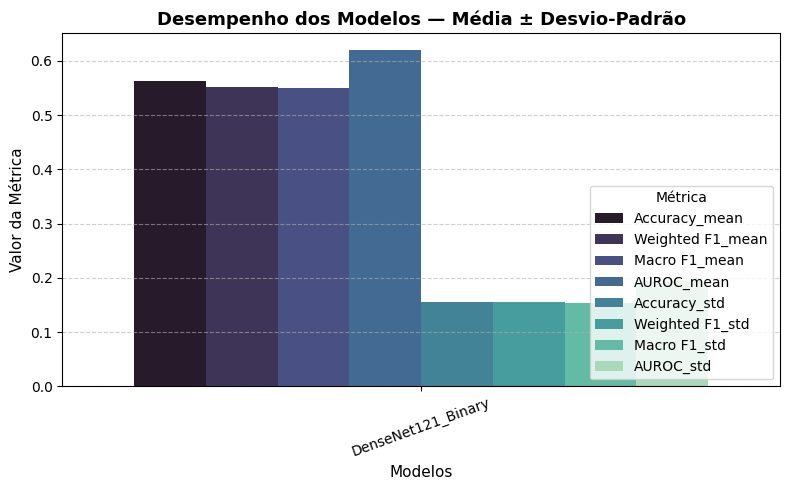

📊 Gráfico salvo em: Trained_Models/Effusion_vs_Pneumonia_metrics.png


In [12]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Effusion vs Pneumonia
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída
os.makedirs("Trained_Models", exist_ok=True)

# Salva CSV
csv_path = "Trained_Models/Effusion_vs_Pneumonia_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe tabela
print("\n📊 Comparação Final (Effusion vs Pneumonia):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo com média e desvio-padrão
# ======================================================
plt.figure(figsize=(8, 5))

# Garante que colunas são strings
comparison_df.columns = comparison_df.columns.astype(str)

# Seleciona colunas de médias e desvios
mean_cols = [c for c in comparison_df.columns if c.endswith("_mean")]
std_cols = [c.replace("_mean", "_std") for c in mean_cols]

# Cria DataFrame em formato "longo" (tidy)
plot_df = comparison_df[mean_cols].reset_index().melt(
    id_vars="index", var_name="metric", value_name="mean"
)

# Adiciona coluna de desvio-padrão correspondente
plot_df["std"] = plot_df.apply(
    lambda row: comparison_df.loc[row["index"], row["metric"].replace("_mean", "_std")]
    if row["metric"].replace("_mean", "_std") in comparison_df.columns else np.nan,
    axis=1
)

# Remove o sufixo "_mean" do nome da métrica
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "", regex=False)

# Cria gráfico com barras e erro
# plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars="index"),
    x="index", y="value", hue="variable", palette="mako",
    err_kws={'color': 'black', 'linewidth': 1}  # ✅ substitui errcolor e errwidth
)


# Títulos e rótulos
plt.title("Desempenho dos Modelos — Média ± Desvio-Padrão", fontsize=13, weight="bold")
plt.xlabel("Modelos", fontsize=11)
plt.ylabel("Valor da Métrica", fontsize=11)
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Effusion_vs_Pneumonia_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")



📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Effusion_vs_Pneumonia_comparison.csv

📊 Comparação Final (Effusion vs Pneumonia):
                    Accuracy  Weighted F1  Macro F1   AUROC
VGG16_Binary          0.8276       0.8251    0.8242  0.8833
ResNet50_Binary       0.7586       0.7551    0.7539  0.8238
DenseNet121_Binary    0.5517       0.4973    0.4912  0.6810


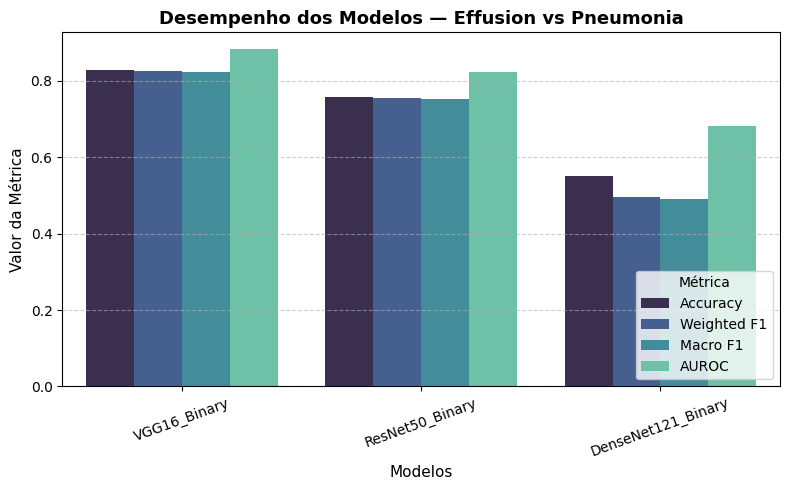

📊 Gráfico salvo em: Trained_Models/Effusion_vs_Pneumonia_metrics.png


In [12]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Effusion vs Pneumonia
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída (caso não exista)
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados dos modelos em DataFrame
comparison_df = pd.DataFrame(binary_results_eff_vs_pneu).T
comparison_df = comparison_df.round(4)

# Caminho de salvamento
csv_path = "Trained_Models/Effusion_vs_Pneumonia_comparison.csv"

# Salva CSV com o resumo
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe tabela no console
print("\n📊 Comparação Final (Effusion vs Pneumonia):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho
# ======================================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars="index"),
    x="index", y="value", hue="variable", palette="mako"
)

plt.title("Desempenho dos Modelos — Effusion vs Pneumonia", fontsize=13, weight="bold")
plt.xlabel("Modelos", fontsize=11)
plt.ylabel("Valor da Métrica", fontsize=11)
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Effusion_vs_Pneumonia_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")


#### Cardiomegaly vs Atelectasis

In [13]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121, build_xception, build_custom_cnn,
    train_and_evaluate
)

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
CARDIO_IDX = 1  # substitua pelos índices corretos conforme seu CLASS_NAMES
ATELECTASIS_IDX = 2
BINARY_CLASSES = ["Cardiomegaly", "Atelectasis"]

# ======================================================
# 📂 Carregamento dos datasets (224x224)
# ======================================================

# 🔹 Treino — combina originais e sintéticos
train_orig = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_ds = train_orig.concatenate(train_synth)  # junta os dois conjuntos

# 🔹 Validação e teste — somente dados reais
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224, 224), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224, 224), batch_size=BATCH_SIZE
)

# ======================================================
# ⚙️ Filtragem binária (Cardiomegaly vs Atelectasis)
# ======================================================
train_ds_binary = filter_and_remap(train_ds, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)
val_ds_binary = filter_and_remap(val_ds, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)
test_ds_binary = filter_and_remap(test_ds, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================

# 🔹 Treino (originais + sintéticos)
train_orig_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_ds_xcep = train_orig_xcep.concatenate(train_synth_xcep)

# 🔹 Validação e teste (somente originais)
val_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(299, 299), batch_size=BATCH_SIZE
)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(299, 299), batch_size=BATCH_SIZE
)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)
val_ds_xcep_bin = filter_and_remap(val_ds_xcep, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)
test_ds_xcep_bin = filter_and_remap(test_ds_xcep, CARDIO_IDX, ATELECTASIS_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos para treino binário
# ======================================================
model_configs = [
    (build_vgg16, (224, 224, 3), "VGG16_Binary"),
    (build_resnet50, (224, 224, 3), "ResNet50_Binary"),
    (build_densenet121, (224, 224, 3), "DenseNet121_Binary"),
    # Se quiser incluir Xception:
    # (build_xception, (299, 299, 3), "Xception_Binary")
]

# ======================================================
# 🚀 Loop de treinamento — Cardiomegaly vs Atelectasis
# ======================================================
binary_results_cm_vs_at = {}
binary_histories = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Cardiomegaly vs Atelectasis ...")

    if name == "Xception_Binary":
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model, train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
            BINARY_CLASSES, epochs=50, title=name
        )
    else:
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model, train_ds_binary, val_ds_binary, test_ds_binary,
            BINARY_CLASSES, epochs=50, title=name
        )

    binary_results_cm_vs_at[name] = metrics
    binary_histories[name] = history

    print(f"✅ {name} concluído — Métricas:", metrics)

print("\n🎯 Treinamento completo para todas as arquiteturas (Cardiomegaly vs Atelectasis).")


Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando VGG16_Binary — Cardiomegaly vs Atelectasis ...
Epoch 1/50
     34/Unknown - 49s 1s/step - loss: 8.4010 - accuracy: 0.5185

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 53s 2s/step - loss: 8.4010 - accuracy: 0.5185 - val_loss: 7.4783 - val_accuracy: 0.6667
Epoch 2/50
34/34 [==============================] - 49s 1s/step - loss: 2.1622 - accuracy: 0.7444 - val_loss: 4.6295 - val_accuracy: 0.7000
Epoch 3/50
34/34 [==============================] - 51s 1s/step - loss: 0.7188 - accuracy: 0.8463 - val_loss: 8.0980 - val_accuracy: 0.5333
Epoch 4/50
34/34 [==============================] - 48s 1s/step - loss: 1.0849 - accuracy: 0.8278 - val_loss: 7.9612 - val_accuracy: 0.5000
Epoch 5/50
34/34 [==============================] - 49s 1s/step - loss: 0.4575 - accuracy: 0.9093 - val_loss: 2.8213 - val_accuracy: 0.5333
Epoch 6/50
34/34 [==============================] - 50s 1s/step - loss: 0.1703 - accuracy: 0.9500 - val_loss: 3.7576 - val_accuracy: 0.6667
Epoch 7/50
34/34 [==============================] - 50s 1s/step - loss: 0.1500 - accuracy: 0.9648 - val_loss: 2.5748 - val_accuracy: 0.5333
Epoch 8/50
34/34 [=============

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 34s 890ms/step - loss: 0.7333 - accuracy: 0.5333 - val_loss: 0.7557 - val_accuracy: 0.4667
Epoch 2/50
34/34 [==============================] - 31s 886ms/step - loss: 0.6993 - accuracy: 0.5574 - val_loss: 0.7464 - val_accuracy: 0.4333
Epoch 3/50
34/34 [==============================] - 30s 847ms/step - loss: 0.6778 - accuracy: 0.5815 - val_loss: 0.7430 - val_accuracy: 0.4333
Epoch 4/50
34/34 [==============================] - 29s 825ms/step - loss: 0.6580 - accuracy: 0.5870 - val_loss: 0.7337 - val_accuracy: 0.4333
Epoch 5/50
34/34 [==============================] - 30s 859ms/step - loss: 0.6373 - accuracy: 0.6185 - val_loss: 0.7252 - val_accuracy: 0.4667
Epoch 6/50
34/34 [==============================] - 31s 895ms/step - loss: 0.6205 - accuracy: 0.6426 - val_loss: 0.7196 - val_accuracy: 0.5000
Epoch 7/50
34/34 [==============================] - 30s 882ms/step - loss: 0.6075 - accuracy: 0.6519 - val_loss: 0.7154 - val_accuracy: 0.5333
Epoch 8/50

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 44s 1s/step - loss: 1.4741 - accuracy: 0.5000 - val_loss: 1.9291 - val_accuracy: 0.3667
Epoch 2/50
34/34 [==============================] - 32s 918ms/step - loss: 1.1075 - accuracy: 0.4963 - val_loss: 1.6780 - val_accuracy: 0.3333
Epoch 3/50
34/34 [==============================] - 32s 916ms/step - loss: 1.0566 - accuracy: 0.4926 - val_loss: 1.6113 - val_accuracy: 0.3333
Epoch 4/50
34/34 [==============================] - 31s 905ms/step - loss: 1.0123 - accuracy: 0.4944 - val_loss: 1.5024 - val_accuracy: 0.2667
Epoch 5/50
34/34 [==============================] - 32s 920ms/step - loss: 0.9835 - accuracy: 0.5019 - val_loss: 1.4416 - val_accuracy: 0.2667
Epoch 6/50
34/34 [==============================] - 34s 1s/step - loss: 0.9506 - accuracy: 0.5019 - val_loss: 1.4019 - val_accuracy: 0.2667
Epoch 7/50
34/34 [==============================] - 33s 968ms/step - loss: 0.9266 - accuracy: 0.5222 - val_loss: 1.3813 - val_accuracy: 0.2667
Epoch 8/50
34/34


📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Cardiomegaly_vs_Atelectasis_comparison.csv

📊 Comparação Final (Cardiomegaly vs Atelectasis):
                    Accuracy  Weighted F1  Macro F1   AUROC
VGG16_Binary          0.4000       0.3250    0.3250  0.5867
ResNet50_Binary       0.5667       0.5543    0.5543  0.5333
DenseNet121_Binary    0.4667       0.4667    0.4667  0.4222


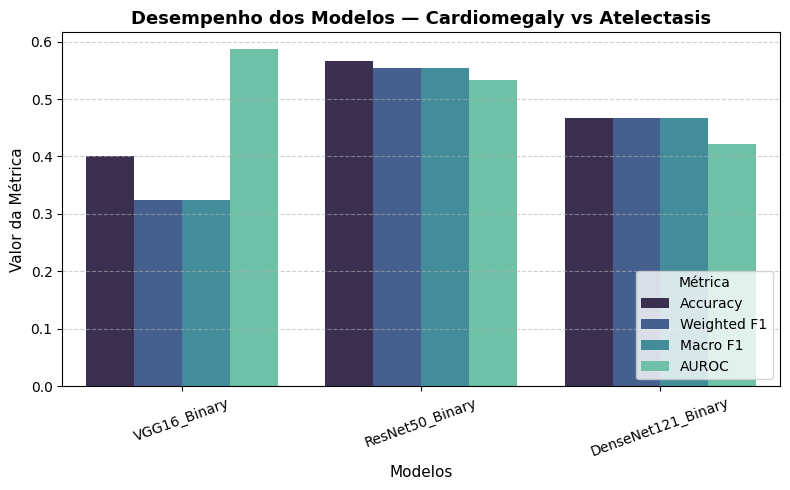

📊 Gráfico salvo em: Trained_Models/Cardiomegaly_vs_Atelectasis_metrics.png


In [14]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Cardiomegaly vs Atelectasis
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída (caso não exista)
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados dos modelos em DataFrame
comparison_df = pd.DataFrame(binary_results_cm_vs_at).T
comparison_df = comparison_df.round(4)

# Caminho de salvamento CSV
csv_path = "Trained_Models/Cardiomegaly_vs_Atelectasis_comparison.csv"

# Salva CSV com o resumo
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe tabela no console
print("\n📊 Comparação Final (Cardiomegaly vs Atelectasis):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho
# ======================================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars="index"),
    x="index", y="value", hue="variable", palette="mako"
)

plt.title("Desempenho dos Modelos — Cardiomegaly vs Atelectasis", fontsize=13, weight="bold")
plt.xlabel("Modelos", fontsize=11)
plt.ylabel("Valor da Métrica", fontsize=11)
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Cardiomegaly_vs_Atelectasis_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")


#### Effusion vs Cardiomegaly

In [15]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121, build_xception, build_custom_cnn,
    train_and_evaluate
)

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
BINARY_CLASSES = ["Effusion", "Cardiomegaly"]

# 🔹 Definir índices das classes (ajuste conforme seu CLASS_NAMES)
EFFUSION_IDX = CLASS_NAMES.index("Effusion")
CARDIO_IDX = CLASS_NAMES.index("Cardiomegaly")

print(f"Índices encontrados — Effusion: {EFFUSION_IDX}, Cardiomegaly: {CARDIO_IDX}")

# ======================================================
# 📂 Carregamento dos datasets (224x224)
# ======================================================

# 🔹 Treinamento — combina dados reais + sintéticos
train_real = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(224, 224), batch_size=BATCH_SIZE
)
train_ds = train_real.concatenate(train_synth)

# 🔹 Validação e teste — apenas dados reais
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(224, 224), batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(224, 224), batch_size=BATCH_SIZE
)

# ======================================================
# ⚙️ Filtragem binária (Effusion vs Cardiomegaly)
# ======================================================
train_ds_binary = filter_and_remap(train_ds, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)
val_ds_binary = filter_and_remap(val_ds, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)
test_ds_binary = filter_and_remap(test_ds, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================

# 🔹 Treino (reais + sintéticos)
train_real_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(
    "../generated/train", image_size=(299, 299), batch_size=BATCH_SIZE
)
train_ds_xcep = train_real_xcep.concatenate(train_synth_xcep)

# 🔹 Validação e teste (apenas reais)
val_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/val", image_size=(299, 299), batch_size=BATCH_SIZE
)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(
    "../data/test", image_size=(299, 299), batch_size=BATCH_SIZE
)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)
val_ds_xcep_bin = filter_and_remap(val_ds_xcep, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)
test_ds_xcep_bin = filter_and_remap(test_ds_xcep, EFFUSION_IDX, CARDIO_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos para treinamento binário
# ======================================================
model_configs = [
    (build_vgg16, (224, 224, 3), "VGG16_Binary"),
    (build_resnet50, (224, 224, 3), "ResNet50_Binary"),
    (build_densenet121, (224, 224, 3), "DenseNet121_Binary"),
    # Se desejar incluir Xception:
    # (build_xception, (299, 299, 3), "Xception_Binary")
]

# ======================================================
# 🚀 Loop de Treinamento — Effusion vs Cardiomegaly
# ======================================================
binary_results_eff_vs_cardio = {}
binary_histories = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Effusion vs Cardiomegaly ...")

    # Cria o modelo e executa o treino
    if name == "Xception_Binary":
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
            BINARY_CLASSES, epochs=50, title=name
        )
    else:
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_binary, val_ds_binary, test_ds_binary,
            BINARY_CLASSES, epochs=50, title=name
        )

    # Armazena resultados e histórico
    binary_results_eff_vs_cardio[name] = metrics
    binary_histories[name] = history

    print(f"✅ {name} concluído — Métricas:", metrics)

print("\n🎯 Treinamento completo para todas as arquiteturas (Effusion vs Cardiomegaly).")


Índices encontrados — Effusion: 2, Cardiomegaly: 1
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando VGG16_Binary — Effusion vs Cardiomegaly ...
Epoch 1/50
     34/Unknown - 51s 1s/step - loss: 8.1357 - accuracy: 0.5426

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 55s 2s/step - loss: 8.1357 - accuracy: 0.5426 - val_loss: 9.0133 - val_accuracy: 0.6333
Epoch 2/50
34/34 [==============================] - 50s 1s/step - loss: 2.4940 - accuracy: 0.7704 - val_loss: 11.8636 - val_accuracy: 0.5333
Epoch 3/50
34/34 [==============================] - 49s 1s/step - loss: 1.2765 - accuracy: 0.8444 - val_loss: 9.0283 - val_accuracy: 0.4667
Epoch 4/50
34/34 [==============================] - 50s 1s/step - loss: 1.4874 - accuracy: 0.8093 - val_loss: 4.2920 - val_accuracy: 0.6000
Epoch 5/50
34/34 [==============================] - 50s 1s/step - loss: 0.5413 - accuracy: 0.9167 - val_loss: 7.1382 - val_accuracy: 0.7000
Epoch 6/50
34/34 [==============================] - 51s 1s/step - loss: 0.2306 - accuracy: 0.9500 - val_loss: 4.8644 - val_accuracy: 0.7000
Epoch 7/50
34/34 [==============================] - 49s 1s/step - loss: 0.0897 - accuracy: 0.9722 - val_loss: 4.3568 - val_accuracy: 0.7000
Epoch 8/50
34/34 [============

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 34s 898ms/step - loss: 0.7856 - accuracy: 0.5204 - val_loss: 0.8853 - val_accuracy: 0.5667
Epoch 2/50
34/34 [==============================] - 29s 851ms/step - loss: 0.7384 - accuracy: 0.5648 - val_loss: 0.8500 - val_accuracy: 0.4000
Epoch 3/50
34/34 [==============================] - 30s 866ms/step - loss: 0.7001 - accuracy: 0.5574 - val_loss: 0.8453 - val_accuracy: 0.4000
Epoch 4/50
34/34 [==============================] - 29s 839ms/step - loss: 0.6742 - accuracy: 0.5907 - val_loss: 0.8723 - val_accuracy: 0.3667
Epoch 5/50
34/34 [==============================] - 28s 819ms/step - loss: 0.6490 - accuracy: 0.6167 - val_loss: 0.8718 - val_accuracy: 0.4000
Epoch 6/50
34/34 [==============================] - 30s 859ms/step - loss: 0.6326 - accuracy: 0.6352 - val_loss: 0.8776 - val_accuracy: 0.4000
Epoch 7/50
34/34 [==============================] - 29s 841ms/step - loss: 0.6177 - accuracy: 0.6574 - val_loss: 0.8825 - val_accuracy: 0.4000
Epoch 8/50

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 47s 1s/step - loss: 2.2321 - accuracy: 0.5019 - val_loss: 1.8037 - val_accuracy: 0.4667
Epoch 2/50
34/34 [==============================] - 35s 988ms/step - loss: 1.6832 - accuracy: 0.5074 - val_loss: 1.4199 - val_accuracy: 0.5333
Epoch 3/50
34/34 [==============================] - 31s 900ms/step - loss: 1.4808 - accuracy: 0.4907 - val_loss: 1.3295 - val_accuracy: 0.5333
Epoch 4/50
34/34 [==============================] - 31s 905ms/step - loss: 1.3985 - accuracy: 0.4759 - val_loss: 1.2133 - val_accuracy: 0.5667
Epoch 5/50
34/34 [==============================] - 31s 896ms/step - loss: 1.3046 - accuracy: 0.4741 - val_loss: 1.1617 - val_accuracy: 0.5333
Epoch 6/50
34/34 [==============================] - 34s 995ms/step - loss: 1.2477 - accuracy: 0.4630 - val_loss: 1.1500 - val_accuracy: 0.4333
Epoch 7/50
34/34 [==============================] - 31s 899ms/step - loss: 1.1992 - accuracy: 0.4667 - val_loss: 1.1430 - val_accuracy: 0.4667
Epoch 8/50
34


📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Effusion_vs_Cardiomegaly_comparison.csv

📊 Comparação Final (Effusion vs Cardiomegaly):
                    Accuracy  Weighted F1  Macro F1   AUROC
VGG16_Binary          0.4333       0.4007    0.4007  0.5144
ResNet50_Binary       0.5333       0.5333    0.5333  0.4622
DenseNet121_Binary    0.5000       0.4949    0.4949  0.6089


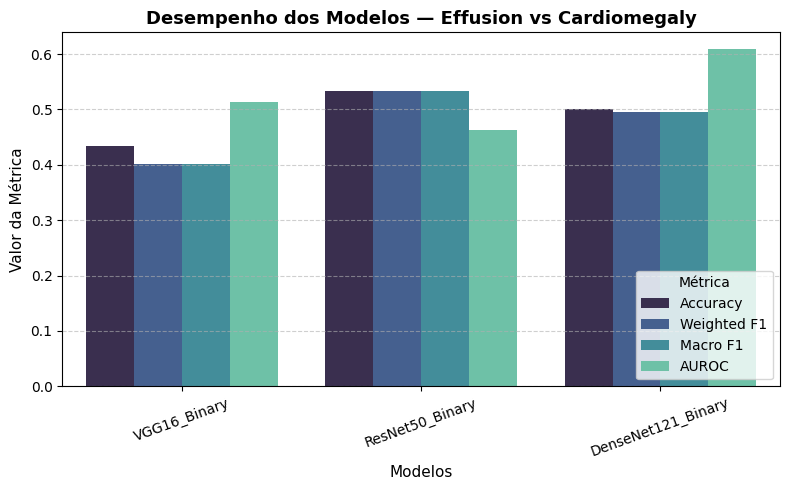

📊 Gráfico salvo em: Trained_Models/Effusion_vs_Cardiomegaly_metrics.png


In [16]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Effusion vs Cardiomegaly
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída (caso não exista)
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados dos modelos em DataFrame
comparison_df = pd.DataFrame(binary_results_eff_vs_cardio).T
comparison_df = comparison_df.round(4)

# Caminho de salvamento CSV
csv_path = "Trained_Models/Effusion_vs_Cardiomegaly_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe tabela no console
print("\n📊 Comparação Final (Effusion vs Cardiomegaly):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho
# ======================================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars="index"),
    x="index", y="value", hue="variable", palette="mako"
)

plt.title("Desempenho dos Modelos — Effusion vs Cardiomegaly", fontsize=13, weight="bold")
plt.xlabel("Modelos", fontsize=11)
plt.ylabel("Valor da Métrica", fontsize=11)
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Effusion_vs_Cardiomegaly_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")


#### Effusion vs Atelectasis

In [30]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from src.VGG_help import (
    build_vgg16, build_resnet50, build_densenet121,
    build_xception, build_custom_cnn, train_and_evaluate
)

# ======================================================
# 🔧 Configurações gerais
# ======================================================
BATCH_SIZE = 16
NUM_CLASSES_BINARY = 2
BINARY_CLASSES = ["Effusion", "Atelectasis"]

# ======================================================
# 📂 Função auxiliar para filtrar duas classes
# ======================================================
def filter_and_remap(dataset, idx_class1, idx_class2, batch_size):
    dataset = dataset.unbatch()  # remove batching para filtragem correta

    def filter_fn(image, label):
        return tf.logical_or(tf.equal(label, idx_class1),
                             tf.equal(label, idx_class2))

    def map_fn(image, label):
        new_label = tf.cond(tf.equal(label, idx_class1),
                            lambda: tf.constant(0, dtype=tf.int32),
                            lambda: tf.constant(1, dtype=tf.int32))
        return image, new_label

    dataset_filtered = dataset.filter(filter_fn).map(map_fn)
    return dataset_filtered.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ======================================================
# 📂 Carregamento dos datasets
# ======================================================

# Caminhos
real_train_dir = "../data/train"
real_val_dir   = "../data/val"
real_test_dir  = "../data/test"
synthetic_train_dir = "../generated/train"

# Dados de treino (reais + sintéticos)
train_real = tf.keras.utils.image_dataset_from_directory(
    real_train_dir, image_size=(224, 224), batch_size=BATCH_SIZE
)
train_synth = tf.keras.utils.image_dataset_from_directory(
    synthetic_train_dir, image_size=(224, 224), batch_size=BATCH_SIZE
) if tf.io.gfile.exists(synthetic_train_dir) else None

if train_synth:
    print("🔄 Combinando dados reais e sintéticos para o treino...")
    train_combined = train_real.concatenate(train_synth)
else:
    print("⚠️ Nenhum conjunto sintético encontrado. Usando apenas dados reais.")
    train_combined = train_real

# Validação e teste (apenas reais)
val_ds = tf.keras.utils.image_dataset_from_directory(real_val_dir, image_size=(224, 224), batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(real_test_dir, image_size=(224, 224), batch_size=BATCH_SIZE)

# ======================================================
# 🔹 Obter nomes das classes para definir índices
# ======================================================
CLASS_NAMES = train_real.class_names
EFFUSION_IDX = CLASS_NAMES.index("Effusion")
ATELECTASIS_IDX = CLASS_NAMES.index("Atelectasis")
print(f"Índices encontrados — Effusion: {EFFUSION_IDX}, Atelectasis: {ATELECTASIS_IDX}")

# ======================================================
# ⚙️ Filtragem binária (Effusion vs Atelectasis)
# ======================================================
train_ds_binary = filter_and_remap(train_combined, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)
val_ds_binary   = filter_and_remap(val_ds, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)
test_ds_binary  = filter_and_remap(test_ds, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)

# ======================================================
# 🧠 Datasets para Xception (299x299)
# ======================================================
train_real_xcep = tf.keras.utils.image_dataset_from_directory(real_train_dir, image_size=(299, 299), batch_size=BATCH_SIZE)
train_synth_xcep = tf.keras.utils.image_dataset_from_directory(synthetic_train_dir, image_size=(299, 299), batch_size=BATCH_SIZE) if tf.io.gfile.exists(synthetic_train_dir) else None
train_ds_xcep = train_real_xcep.concatenate(train_synth_xcep) if train_synth_xcep else train_real_xcep

val_ds_xcep = tf.keras.utils.image_dataset_from_directory(real_val_dir, image_size=(299, 299), batch_size=BATCH_SIZE)
test_ds_xcep = tf.keras.utils.image_dataset_from_directory(real_test_dir, image_size=(299, 299), batch_size=BATCH_SIZE)

train_ds_xcep_bin = filter_and_remap(train_ds_xcep, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)
val_ds_xcep_bin   = filter_and_remap(val_ds_xcep, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)
test_ds_xcep_bin  = filter_and_remap(test_ds_xcep, EFFUSION_IDX, ATELECTASIS_IDX, BATCH_SIZE)

# ======================================================
# 🏗️ Lista de modelos para treinamento binário
# ======================================================
model_configs = [
    (build_vgg16, (224, 224, 3), "VGG16_Binary"),
    (build_resnet50, (224, 224, 3), "ResNet50_Binary"),
    (build_densenet121, (224, 224, 3), "DenseNet121_Binary")
]

# ======================================================
# 🚀 Loop de Treinamento — Effusion vs Atelectasis
# ======================================================
binary_results_eff_vs_at = {}
binary_histories = {}

for builder, input_shape, name in model_configs:
    print(f"\n🚀 Treinando {name} — Effusion vs Atelectasis ...")

    if "Xception" in name:
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_xcep_bin, val_ds_xcep_bin, test_ds_xcep_bin,
            BINARY_CLASSES, epochs=50, title=name
        )
    else:
        model = builder(input_shape, NUM_CLASSES_BINARY)
        history, metrics = train_and_evaluate(
            model,
            train_ds_binary, val_ds_binary, test_ds_binary,
            BINARY_CLASSES, epochs=50, title=name
        )

    binary_results_eff_vs_at[name] = metrics
    binary_histories[name] = history

    print(f"✅ {name} concluído — Métricas:", metrics)

print("\n🎯 Treinamento completo para todas as arquiteturas (Effusion vs Atelectasis).")


Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
🔄 Combinando dados reais e sintéticos para o treino...
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.
Índices encontrados — Effusion: 2, Atelectasis: 0
Found 280 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Found 59 files belonging to 4 classes.

🚀 Treinando VGG16_Binary — Effusion vs Atelectasis ...
Epoch 1/50
     34/Unknown - 53s 1s/step - loss: 5.2522 - accuracy: 0.6019

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 58s 2s/step - loss: 5.2522 - accuracy: 0.6019 - val_loss: 13.2003 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 57s 2s/step - loss: 2.2685 - accuracy: 0.7722 - val_loss: 10.0042 - val_accuracy: 0.3667
Epoch 3/50
34/34 [==============================] - 64s 2s/step - loss: 1.6946 - accuracy: 0.8241 - val_loss: 14.8813 - val_accuracy: 0.4667
Epoch 4/50
34/34 [==============================] - 56s 2s/step - loss: 0.6312 - accuracy: 0.9037 - val_loss: 11.0557 - val_accuracy: 0.2667
Epoch 5/50
34/34 [==============================] - 51s 1s/step - loss: 0.5283 - accuracy: 0.9148 - val_loss: 11.9892 - val_accuracy: 0.4333
Epoch 6/50
34/34 [==============================] - 50s 1s/step - loss: 0.3891 - accuracy: 0.9352 - val_loss: 10.7610 - val_accuracy: 0.5667
Epoch 7/50
1/1 [==============================] - 1s 1s/step
✅ Training finished for VGG16_Binary
{'Accuracy': 0.43333333333333335, 'Weighted F1': 0.3023255813953488

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 37s 992ms/step - loss: 0.7593 - accuracy: 0.5778 - val_loss: 0.8487 - val_accuracy: 0.6000
Epoch 2/50
34/34 [==============================] - 30s 859ms/step - loss: 0.6983 - accuracy: 0.6148 - val_loss: 0.7296 - val_accuracy: 0.6333
Epoch 3/50
34/34 [==============================] - 31s 899ms/step - loss: 0.6443 - accuracy: 0.6463 - val_loss: 0.7545 - val_accuracy: 0.6000
Epoch 4/50
34/34 [==============================] - 29s 840ms/step - loss: 0.6164 - accuracy: 0.6537 - val_loss: 0.7695 - val_accuracy: 0.6333
Epoch 5/50
34/34 [==============================] - 30s 866ms/step - loss: 0.5934 - accuracy: 0.6667 - val_loss: 0.7877 - val_accuracy: 0.6000
Epoch 6/50
34/34 [==============================] - 30s 854ms/step - loss: 0.5766 - accuracy: 0.6852 - val_loss: 0.8152 - val_accuracy: 0.6333
Epoch 7/50
1/1 [==============================] - 1s 750ms/step
✅ Training finished for ResNet50_Binary
{'Accuracy': 0.5, 'Weighted F1': 0.48571428571428

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 43s 1s/step - loss: 1.6850 - accuracy: 0.5148 - val_loss: 0.7575 - val_accuracy: 0.6667
Epoch 2/50
34/34 [==============================] - 33s 964ms/step - loss: 1.0806 - accuracy: 0.5204 - val_loss: 0.8275 - val_accuracy: 0.5667
Epoch 3/50
34/34 [==============================] - 32s 933ms/step - loss: 1.0031 - accuracy: 0.5444 - val_loss: 0.6728 - val_accuracy: 0.6667
Epoch 4/50
34/34 [==============================] - 32s 919ms/step - loss: 0.9296 - accuracy: 0.5556 - val_loss: 0.6189 - val_accuracy: 0.6667
Epoch 5/50
34/34 [==============================] - 32s 921ms/step - loss: 0.8913 - accuracy: 0.5704 - val_loss: 0.6094 - val_accuracy: 0.6667
Epoch 6/50
34/34 [==============================] - 32s 918ms/step - loss: 0.8719 - accuracy: 0.5704 - val_loss: 0.6115 - val_accuracy: 0.6667
Epoch 7/50
34/34 [==============================] - 32s 927ms/step - loss: 0.8422 - accuracy: 0.5907 - val_loss: 0.6201 - val_accuracy: 0.7000
Epoch 8/50
34

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/34 [==============================] - 69s 2s/step - loss: 42.2839 - accuracy: 0.5000 - val_loss: 20.2795 - val_accuracy: 0.5000
Epoch 2/50
34/34 [==============================] - 52s 1s/step - loss: 9.5589 - accuracy: 0.4685 - val_loss: 4.9016 - val_accuracy: 0.5000
Epoch 3/50
34/34 [==============================] - 51s 1s/step - loss: 3.8545 - accuracy: 0.4759 - val_loss: 3.8767 - val_accuracy: 0.4333
Epoch 4/50
34/34 [==============================] - 56s 2s/step - loss: 3.3965 - accuracy: 0.4815 - val_loss: 3.6373 - val_accuracy: 0.4333
Epoch 5/50
34/34 [==============================] - 52s 2s/step - loss: 3.1659 - accuracy: 0.4815 - val_loss: 3.5282 - val_accuracy: 0.5667
Epoch 6/50
34/34 [==============================] - 50s 1s/step - loss: 2.8890 - accuracy: 0.4815 - val_loss: 3.2741 - val_accuracy: 0.5333
Epoch 7/50
34/34 [==============================] - 51s 1s/step - loss: 2.6967 - accuracy: 0.4907 - val_loss: 3.1673 - val_accuracy: 0.5667
Epoch 8/50
34/34 [===========


📈 Gerando resumo de desempenho...
📄 Resultados salvos em: Trained_Models/Effusion_vs_Atelectasis_comparison.csv

📊 Comparação Final (Effusion vs Atelectasis):
                    Accuracy  Weighted F1  Macro F1   AUROC
VGG16_Binary          0.4333       0.3023    0.3023  0.4756
ResNet50_Binary       0.5000       0.4857    0.4857  0.5000
DenseNet121_Binary    0.5333       0.4976    0.4976  0.5133
Xception_Binary       0.6000       0.5982    0.5982  0.5978


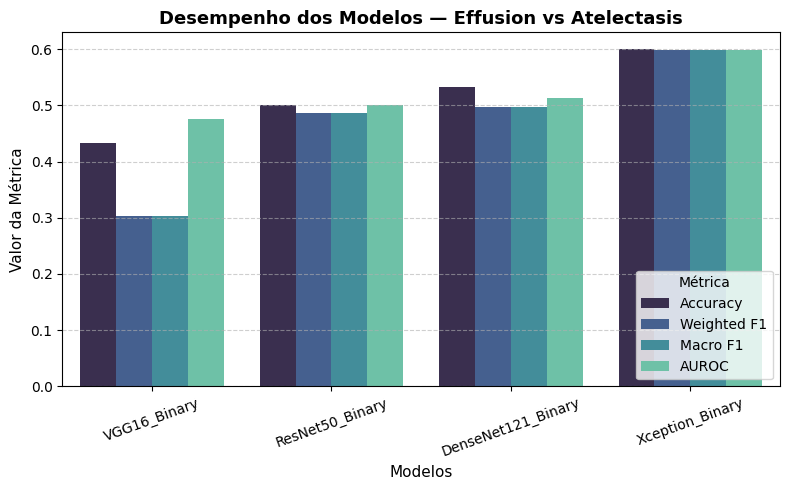

📊 Gráfico salvo em: Trained_Models/Effusion_vs_Atelectasis_metrics.png


In [31]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# 📊 RESUMO E VISUALIZAÇÃO FINAL — Effusion vs Atelectasis
# ======================================================
print("\n📈 Gerando resumo de desempenho...")

# Cria pasta de saída (caso não exista)
os.makedirs("Trained_Models", exist_ok=True)

# Converte resultados dos modelos em DataFrame
comparison_df = pd.DataFrame(binary_results_eff_vs_at).T
comparison_df = comparison_df.round(4)

# Caminho de salvamento CSV
csv_path = "Trained_Models/Effusion_vs_Atelectasis_comparison.csv"
comparison_df.to_csv(csv_path)
print(f"📄 Resultados salvos em: {csv_path}")

# Exibe tabela no console
print("\n📊 Comparação Final (Effusion vs Atelectasis):")
print(comparison_df)

# ======================================================
# 🎨 Gráfico comparativo de desempenho
# ======================================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=comparison_df.reset_index().melt(id_vars="index"),
    x="index", y="value", hue="variable", palette="mako"
)

plt.title("Desempenho dos Modelos — Effusion vs Atelectasis", fontsize=13, weight="bold")
plt.xlabel("Modelos", fontsize=11)
plt.ylabel("Valor da Métrica", fontsize=11)
plt.legend(title="Métrica", loc="lower right")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Salva figura
plot_path = "Trained_Models/Effusion_vs_Atelectasis_metrics.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Gráfico salvo em: {plot_path}")
